# Milestone 3 — Exploratory Data Analysis
## AI Bill Anomaly Detection System

We use **two plotting libraries deliberately**:

- **Matplotlib + Seaborn** — for static, publication-style charts in this notebook (fast,
  clean, standard for exploratory work).
- **Plotly** — for a handful of interactive charts, written as **reusable functions**. These
  same functions get imported directly into the Streamlit dashboard in Milestone 7, so we're
  not duplicating charting logic later.

We also compare distributions **with vs without the injected anomalies** (`True_Anomaly`)
wherever useful — this previews what the Isolation Forest model should be picking up on in
Milestone 5.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("../data/processed/invoices_cleaned.csv", parse_dates=["Invoice_Date"])
print("Shape:", df.shape)
df.head()

Shape: (10200, 10)


,Invoice_ID,Vendor_Name,Department,Invoice_Date,Amount,GST,Quantity,Category,True_Anomaly,IQR_Outlier_Flag
0,INV200078,Vendor_030,Health,2024-01-13,10359.12,12.0,16,Vehicle Maintenance,1,0
1,INV103742,Vendor_031,Administration,2025-04-29,17481.48,5.0,5,Vehicle Maintenance,0,0
2,INV200068,Vendor_024,Water Supply,2025-04-17,21126.69,5.0,23,Electronics,1,0
3,INV105723,Vendor_039,Transport,2025-07-15,11991.82,5.0,33,Office Equipment,0,0
4,INV108987,Vendor_037,Transport,2024-07-12,13688.73,12.0,9,Construction Material,0,0


In [2]:
print(df.info())
print("\nAnomaly rate: {:.2f}%".format(df["True_Anomaly"].mean() * 100))
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Invoice_ID        10200 non-null  str           
 1   Vendor_Name       10200 non-null  str           
 2   Department        10200 non-null  str           
 3   Invoice_Date      10200 non-null  datetime64[us]
 4   Amount            10200 non-null  float64       
 5   GST               10200 non-null  float64       
 6   Quantity          10200 non-null  int64         
 7   Category          10200 non-null  str           
 8   True_Anomaly      10200 non-null  int64         
 9   IQR_Outlier_Flag  10200 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(3), str(4)
memory usage: 797.0 KB
None

Anomaly rate: 8.25%


,Invoice_Date,Amount,GST,Quantity,True_Anomaly,IQR_Outlier_Flag
count,10200,10200.000000,10200.000000,10200.000000,10200.000000,10200.000000
mean,2025-01-01 12:55:54.352941,19458.462288,15.961176,25.009118,0.082549,0.029412
min,2024-01-01 00:00:00,642.560000,1.000000,1.000000,0.000000,0.000000
25%,2024-07-05 00:00:00,11186.965000,5.000000,13.000000,0.000000,0.000000
50%,2025-01-03 00:00:00,16206.955000,18.000000,25.000000,0.000000,0.000000
75%,2025-07-06 00:00:00,20767.050000,28.000000,37.000000,0.000000,0.000000
max,2025-12-31 00:00:00,248768.320000,55.000000,49.000000,1.000000,1.000000
std,NaN,23410.715863,9.036388,14.111855,0.275213,0.168966


## 1. Distribution of Invoice Amounts

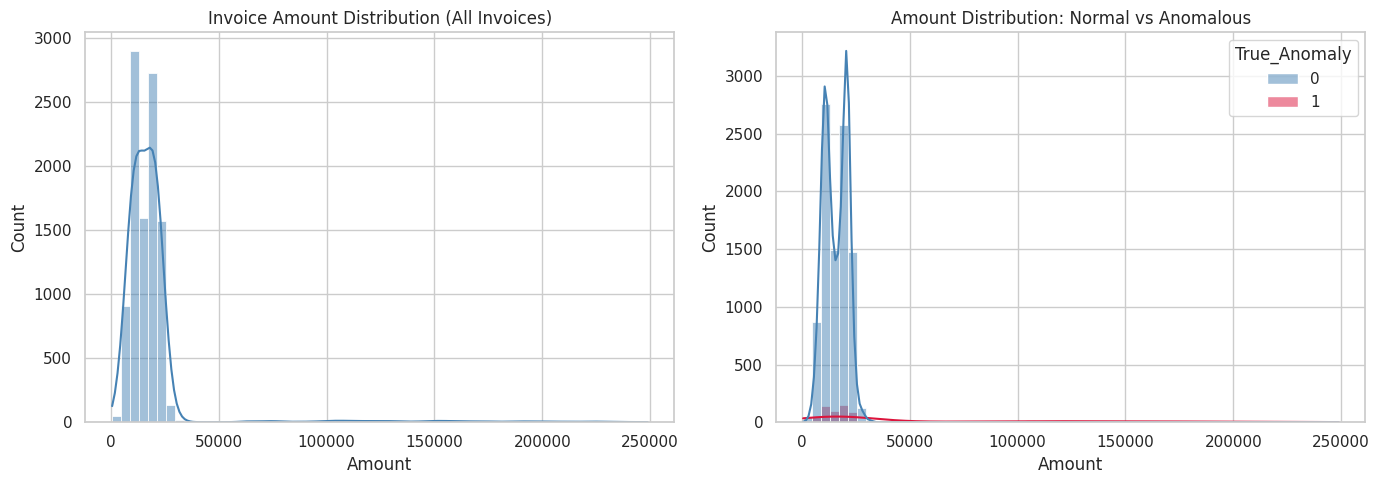

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Amount"], bins=60, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Invoice Amount Distribution (All Invoices)")
axes[0].set_xlabel("Amount")

sns.histplot(data=df, x="Amount", hue="True_Anomaly", bins=60, kde=True,
             ax=axes[1], palette={0: "steelblue", 1: "crimson"})
axes[1].set_title("Amount Distribution: Normal vs Anomalous")
axes[1].set_xlabel("Amount")

plt.tight_layout()
plt.show()

**Observation:** anomalous invoices form a long right tail — this is exactly what
Isolation Forest is good at isolating (points that sit far from the dense cluster of
normal amounts).

## 2. Department-wise Expenditure

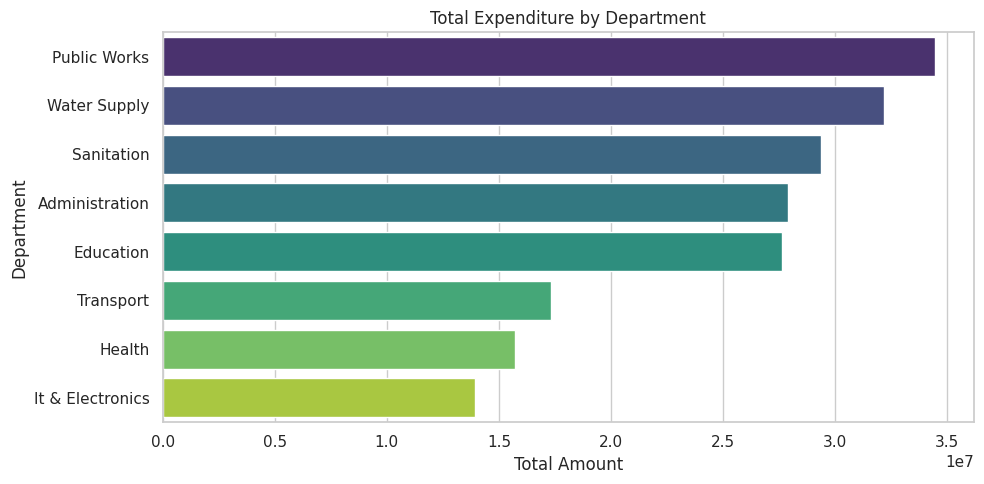

Department
Public Works        34464953.34
Water Supply        32189500.51
Sanitation          29360819.92
Administration      27891144.47
Education           27634615.71
Transport           17317921.73
Health              15707101.23
It & Electronics    13910258.43
Name: Amount, dtype: float64

In [4]:
dept_spend = df.groupby("Department")["Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=dept_spend.values, y=dept_spend.index, hue=dept_spend.index,
            palette="viridis", legend=False)
plt.title("Total Expenditure by Department")
plt.xlabel("Total Amount")
plt.ylabel("Department")
plt.tight_layout()
plt.show()

dept_spend

### Reusable Plotly version (will be imported into the Streamlit dashboard)

In [5]:
def plot_department_spend(dataframe):
    """Interactive department-wise expenditure bar chart. Reused in dashboard/app.py."""
    spend = dataframe.groupby("Department")["Amount"].sum().sort_values(ascending=False).reset_index()
    fig = px.bar(
        spend, x="Amount", y="Department", orientation="h",
        title="Total Expenditure by Department", color="Amount",
        color_continuous_scale="Viridis"
    )
    fig.update_layout(yaxis={"categoryorder": "total ascending"})
    return fig

plot_department_spend(df).show()

## 3. Vendor Frequency

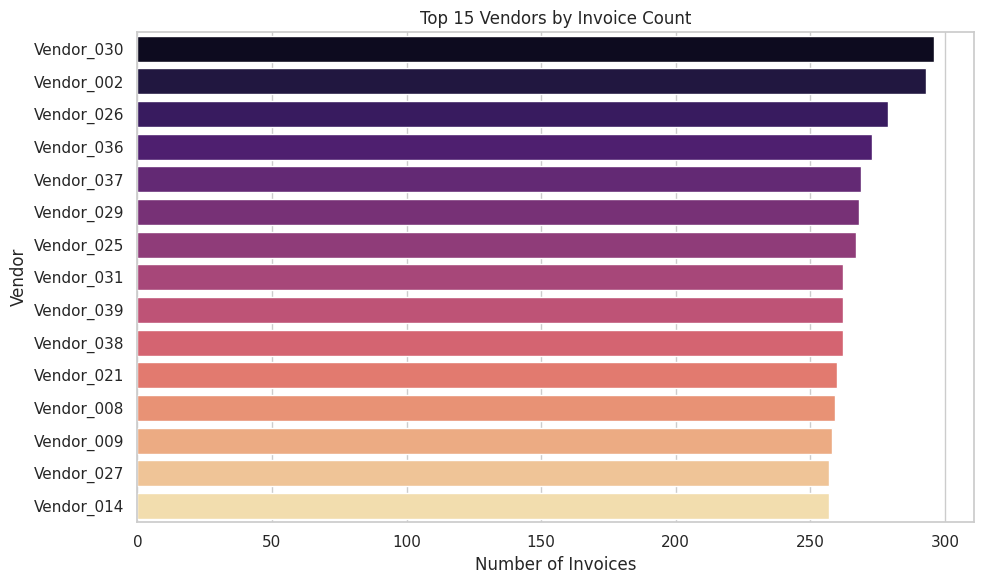

In [6]:
vendor_counts = df["Vendor_Name"].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=vendor_counts.values, y=vendor_counts.index, hue=vendor_counts.index,
            palette="magma", legend=False)
plt.title("Top 15 Vendors by Invoice Count")
plt.xlabel("Number of Invoices")
plt.ylabel("Vendor")
plt.tight_layout()
plt.show()

**Observation:** watch for vendors that sit well above the rest of the pack — in
Milestone 1 we deliberately inflated invoice frequency for two vendors to simulate
shell-vendor-like behavior. They should stand out here.

In [7]:
print("Injected suspicious vendors, invoice counts:")
print(df[df["Vendor_Name"].str.contains("998|999")]["Vendor_Name"].value_counts())

Injected suspicious vendors, invoice counts:
Vendor_Name
Vendor_999    77
Vendor_998    73
Name: count, dtype: int64


## 4. Monthly Expenditure Trend

In [8]:
def plot_monthly_trend(dataframe):
    """Interactive monthly expenditure trend line. Reused in dashboard/app.py."""
    monthly = dataframe.copy()
    monthly["Month"] = monthly["Invoice_Date"].dt.to_period("M").astype(str)
    monthly_spend = monthly.groupby("Month")["Amount"].sum().reset_index()
    fig = px.line(
        monthly_spend, x="Month", y="Amount", markers=True,
        title="Monthly Expenditure Trend"
    )
    fig.update_xaxes(tickangle=45)
    return fig

plot_monthly_trend(df).show()

## 5. GST Distribution

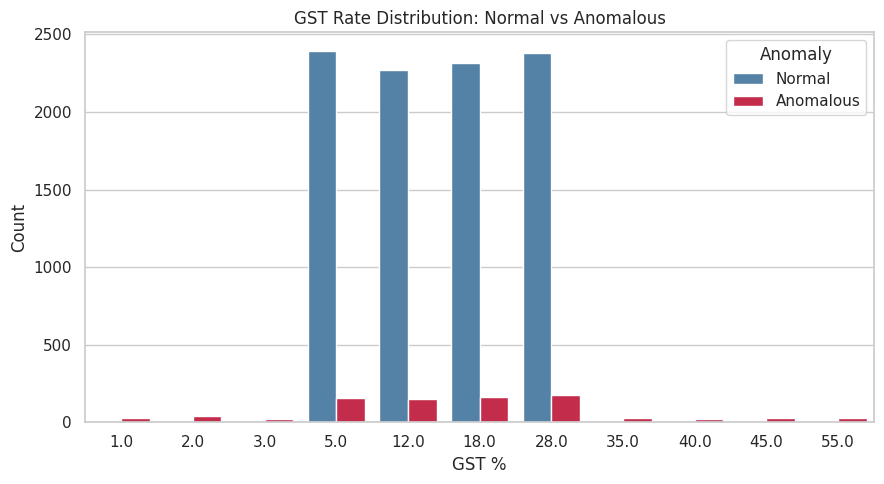

In [9]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="GST", hue="True_Anomaly", palette={0: "steelblue", 1: "crimson"})
plt.title("GST Rate Distribution: Normal vs Anomalous")
plt.xlabel("GST %")
plt.ylabel("Count")
plt.legend(title="Anomaly", labels=["Normal", "Anomalous"])
plt.tight_layout()
plt.show()

**Observation:** standard GST slabs in India are 5, 12, 18, 28%. Any invoice sitting
outside those bars (e.g. 1%, 35%, 55%) is immediately suspicious — this is exactly the
`GST` anomaly type injected in Milestone 1, and it's visually obvious here.

## 6. Correlation Heatmap

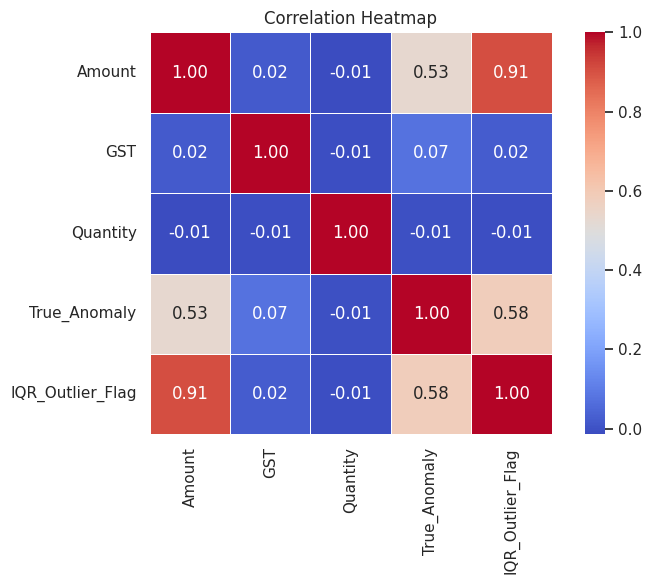

In [10]:
numeric_cols = ["Amount", "GST", "Quantity", "True_Anomaly", "IQR_Outlier_Flag"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**Observation:** correlations between raw numeric fields and `True_Anomaly` are
expectedly weak — anomalies here aren't defined by any single column crossing a
threshold, they're defined by *combinations* (e.g. amount relative to department
average, vendor frequency). This is exactly why Milestone 4 (Feature Engineering)
matters: raw columns alone won't separate anomalies well, engineered relative features
will.

## 7. Amount by Department (Boxplot) — where do outliers cluster?

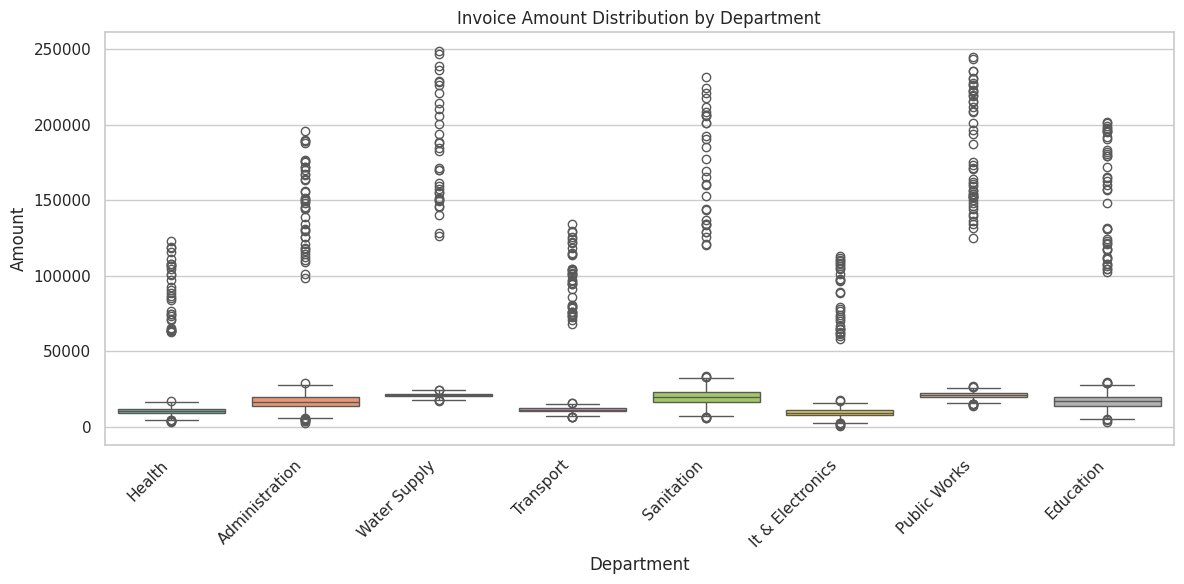

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Department", y="Amount", hue="Department", palette="Set2", legend=False)
plt.xticks(rotation=45, ha="right")
plt.title("Invoice Amount Distribution by Department")
plt.tight_layout()
plt.show()

## Summary of EDA Findings

| Finding | Implication for modeling |
|---|---|
| Amount distribution is right-skewed with anomalies in the tail | Isolation Forest should isolate these well |
| 2 vendors show abnormally high invoice frequency | `Vendor_Frequency` will be a strong engineered feature |
| GST anomalies sit clearly outside standard slabs | `GST` alone is a decent weak signal, but rare |
| Raw column correlations with `True_Anomaly` are weak | Confirms we need **relative/engineered features**, not raw values |
| Department spend varies a lot in scale | Amount needs to be compared **relative to department average**, not in absolute terms |

## Notes for Milestone 4 (Feature Engineering)

Based on this EDA, the features worth engineering are confirmed as:
- `Vendor_Frequency` — invoice count per vendor
- `Dept_Avg_Amount` / `Amount_Deviation` — amount relative to department norm
- `Invoice_Month`, `Invoice_Weekday` — temporal patterns
- `GST_Category` — flag whether GST falls in a standard slab or not

Next notebook: `04_feature_engineering.ipynb`